In [70]:
# Load necessary library
library(fs)
library("ggplot2")
library("tidyverse")


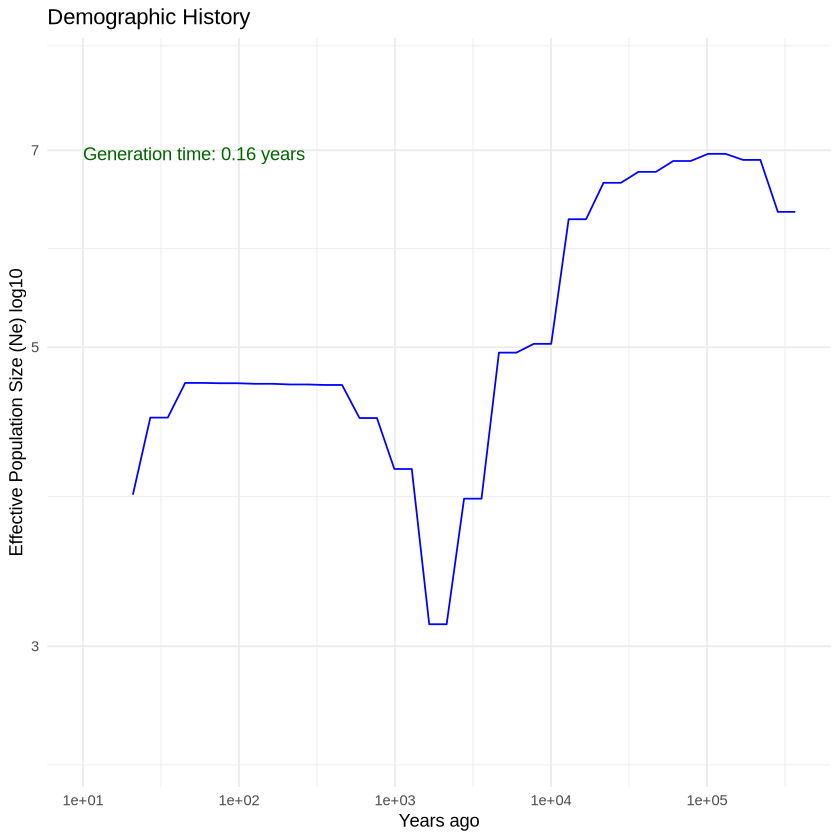

In [72]:

# Provided demography data
demography_data <- data.frame(
  years_ago = c(20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
                75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
                273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
                990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
                3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
                12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
                46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
                169890.48403, 219724.30843, 284175.84417, 367532.89150),
  Ne_log10 = c(3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
               4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
               4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
               4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
               3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
               6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
               6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
               6.885372, 6.885372, 6.300497, 6.300497)
)

# Convert years_ago to generations_ago (assuming generation time of 0.16 years)

# Convert Ne_log10 to actual Ne values

# Plotting using ggplot2
ggplot(demography_data, aes(x = years_ago, y = Ne_log10)) +
  geom_line(color = "blue") +
  scale_x_log10() +
  scale_y_log10(limits = c(2.5, 8)) +  # Adjusting y-axis limits
  labs(title = "Demographic History",
       x = "Years ago",
       y = "Effective Population Size (Ne) log10") +
  theme_minimal() +
  annotate("text", x = 10, y = max(demography_data$Ne_log10, na.rm = TRUE), 
           label = "Generation time: 0.16 years", hjust = 0, color = "darkgreen")


Kingman Plots across different HS

HS 32

In [12]:
# Define the base directory for containing all hidden states replicates.
# This directory should be at least 2 dirs deep and vary in mutation rate
kingman_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_kingman"

# List directories in kingman_dir1 that are exactly two levels deep
kingman_subdirs1 <- list.dirs(kingman_dir1, recursive = TRUE, full.names = TRUE)
kingman_subdirs1 <- kingman_subdirs1[sapply(strsplit(kingman_subdirs1, "/"), length) == length(strsplit(kingman_dir1, "/")[[1]]) + 2]

# Initialize a list to store kingman directories categorized by mutation rate
kingman_dirs_by_mutation_rate <- list()

# Loop through each kingman directory and categorize based on mutation rate
for (kingman_dir in kingman_subdirs1) {
  # Extract the second-to-last directory as the mutation rate identifier
  mutation_rate_dir <- basename(dirname(kingman_dir))
  print(mutation_rate_dir)
  # Store the directories under the mutation rate
  if (!is.null(kingman_dirs_by_mutation_rate[[mutation_rate_dir]])) {
    kingman_dirs_by_mutation_rate[[mutation_rate_dir]] <- c(kingman_dirs_by_mutation_rate[[mutation_rate_dir]], kingman_dir)
  } else {
    kingman_dirs_by_mutation_rate[[mutation_rate_dir]] <- list(kingman_dir)
  }
}

# Format the output for better readability
kingman_dirs_by_mutation_rate


list()

In [13]:
# Format the kingman directories by mutation rate
formatted_kingman_dirs <- lapply(names(kingman_dirs_by_mutation_rate), function(mutation_rate) {
  list(
    mutation_rate = mutation_rate,
    kingman_dirs = kingman_dirs_by_mutation_rate[[mutation_rate]]
  )
})

# Display the categorized kingman directories
print("Kingman Directories Categorized by Mutation Rate:")
print(formatted_kingman_dirs)



[1] "Kingman Directories Categorized by Mutation Rate:"
list()


In [11]:
# Initialize a list to store the paths of .rds files from kingman directories
rds_files_list <- list()

# Loop through each formatted kingman directory group
for (i in seq_along(formatted_kingman_dirs)) {
  # Get the mutation rate (kingman directory identifier)
  mutation_rate <- formatted_kingman_dirs[[i]]$mutation_rate
  
  # Get the kingman directories
  kingman_dirs <- formatted_kingman_dirs[[i]]$kingman_dirs
  
  # Collect the .rds files from each kingman directory
  rds_files_kingman <- unlist(lapply(kingman_dirs, function(kingman_dir) {
    list.files(path = kingman_dir, pattern = "\\.rds$", full.names = TRUE)
  }))
  
  # Store the results in the list
  rds_files_list[[mutation_rate]] <- rds_files_kingman
}

# Print the list of .rds files, categorized by mutation rate
print(rds_files_list)



$SMBC_outs
character(0)



In [186]:
# Constants
gen_times <- 0.16

# Initialize a nested list to store data grouped by HS and mutation rate
hs_mu_grouped_data <- list()

# Process 'kingman' files
for (j in seq_along(rds_files_list[[1]])) {
  kingman_dir <- rds_files_list[[1]][j]
  
  # Extract the HS, mutation rate (mu) from the directory name
  path_components <- unlist(strsplit(kingman_dir, "/"))
  hs_identifier <- path_components[length(path_components) - 2]    # HS identifier (e.g., "HS_20")
  mutr_identifier <- path_components[length(path_components) - 1] # Mutation rate (e.g., "1e-07")
  mutr_numeric <- as.numeric(sub(".*(\\d+e[+-]?\\d+).*", "\\1", mutr_identifier))
  #print(mutr_numeric)
  if (file.exists(kingman_dir)) {
    data_esmc <- readRDS(kingman_dir)  # Read the .rds file

    # Perform calculations
    Ne_t <- data_esmc$Xi
    Ne <- mean(data_esmc$mu / mutr_numeric)
    alpha <- 2  # Set fixed alpha to 2 for Kingman model
    # Calculate years ago and log10 of Ne
    data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
    data_esmc$Ne <- log10(Ne_t * Ne)
    
    # Create a data frame for this file
    df <- data.frame(
      years_ago = data_esmc$years_ago,
      Ne = data_esmc$Ne,
      alpha_sim = alpha,
      alpha_inf = data_esmc$alpha  # Inferred alpha is also 2
    )
    
    # Group data by HS and mutation rate
    if (is.null(hs_mu_grouped_data[[hs_identifier]])) {
      hs_mu_grouped_data[[hs_identifier]] <- list()
    }
    if (is.null(hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]])) {
      hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]] <- list()
    }
    hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]] <- append(
      hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]],
      list(df)
    )
  } else {
    warning(paste("Kingman directory does not exist:", kingman_dir))
  }
}


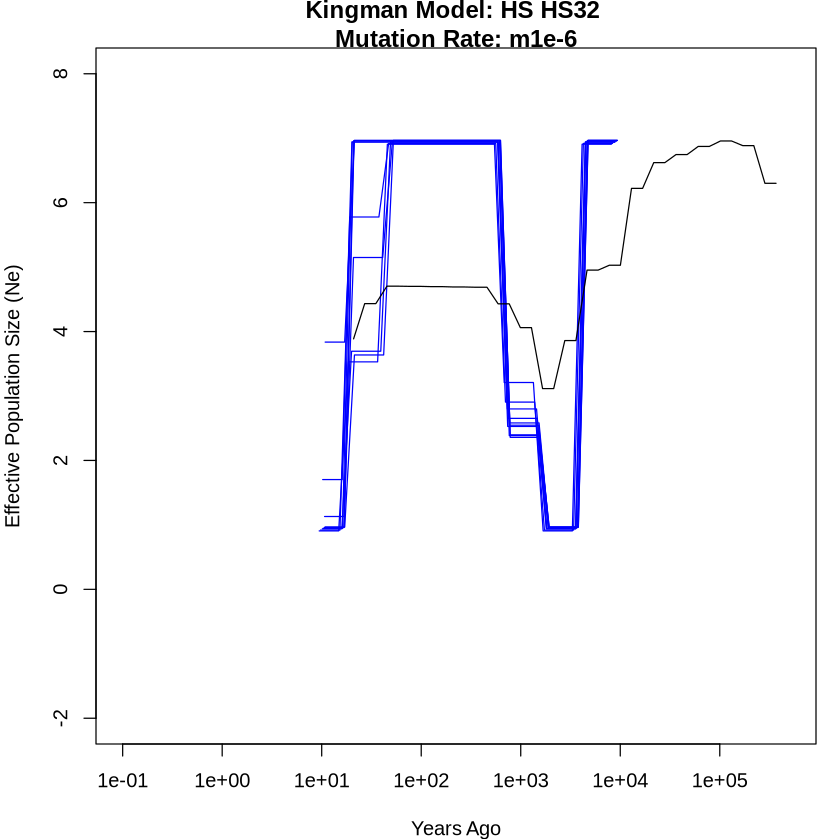

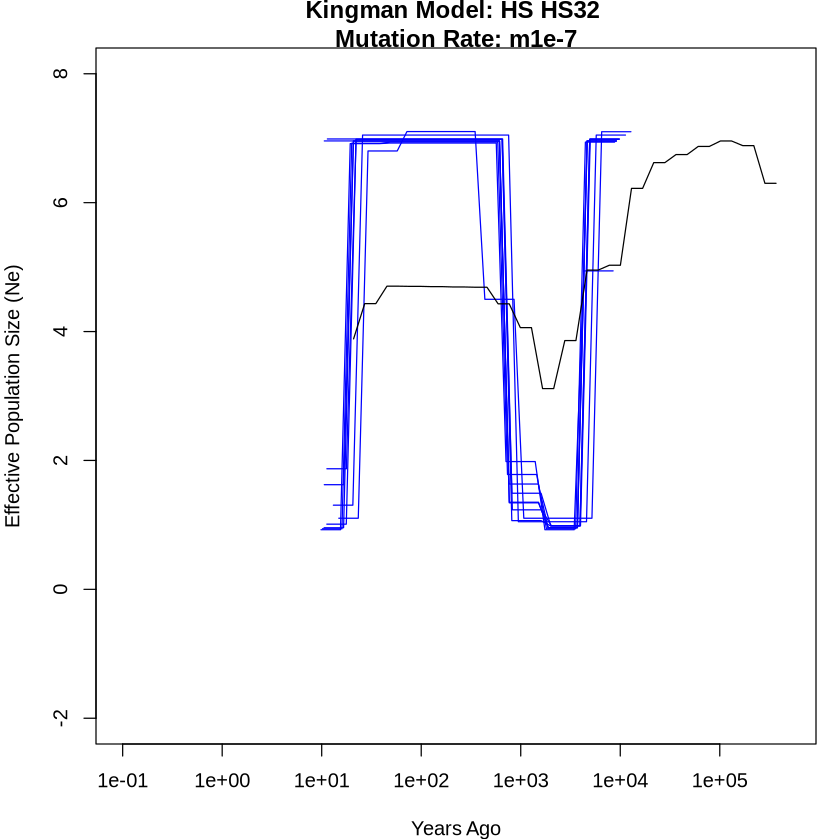

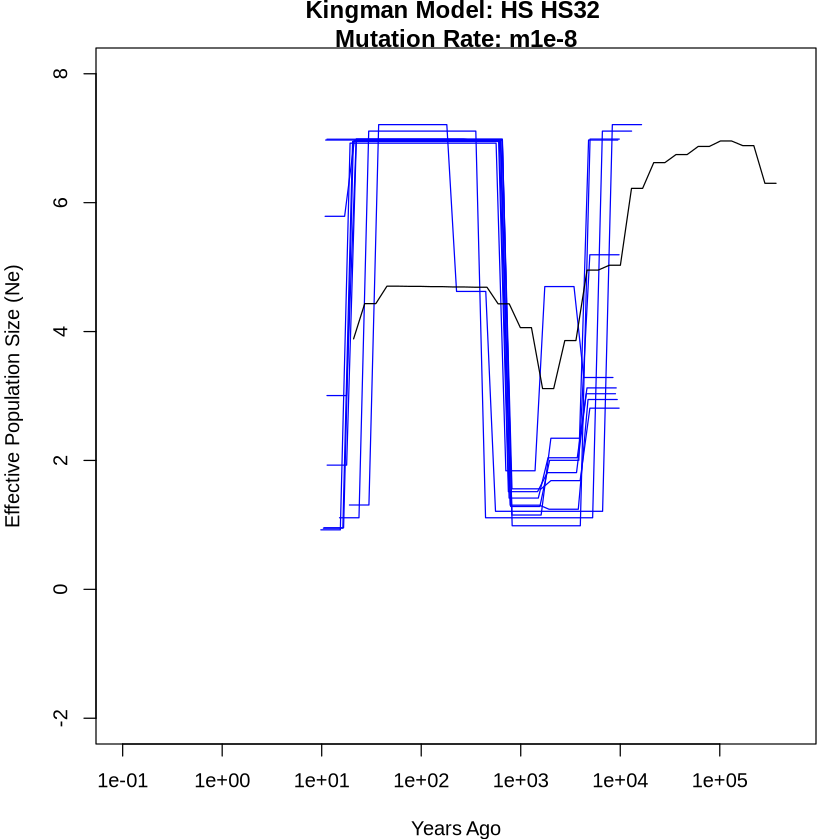

In [187]:

# Loop through each HS and mutation rate group and create plots
for (hs in names(hs_mu_grouped_data)) {
  for (mutr in names(hs_mu_grouped_data[[hs]])) {
    # Get the data frames for this HS and mutation rate group
    kingman_lines <- hs_mu_grouped_data[[hs]][[mutr]]

    # Set up 2x2 layout for plotting
    par( mar = c(4, 4, 2, 1), bg = "white")  # 2x2 layout for subplots
    
    # Plot for the current HS and mutation rate combination
    # Create an empty plot
    plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
         xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
         main = paste("Kingman Model: HS", hs, "\nMutation Rate:", mutr),
         log = "x", col = "black")
    
    # Plot the line for the Kingman model (alpha = 2) for this mutation rate and HS
    for (i in seq_along(kingman_lines)) {
      lines(kingman_lines[[i]]$years_ago, kingman_lines[[i]]$Ne, 
            type = "l", lty = 1, col = "blue")  # Plot with a fixed color
    }
    
    # Optional: Plot the overall demography line in black for comparison
    lines(demography_data$years_ago, demography_data$Ne, 
          type = "l", lty = 1, col = "black")  # Black overall demography line
  }
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")


In [189]:
alpha_data

alpha_sim,alpha_inf
<dbl>,<dbl>
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1


In [191]:
# Initialize a list to collect alpha_sim and alpha_inf for each HS and mutation rate combination
alpha_data <- list()

# Loop through each HS and mutation rate group to collect alpha_sim and alpha_inf
for (hs in names(hs_mu_grouped_data)) {
  for (mutr in names(hs_mu_grouped_data[[hs]])) {
    # Get the data frames for this HS and mutation rate group
    kingman_lines <- hs_mu_grouped_data[[hs]][[mutr]]
     # Initialize vectors to store alpha_sim and alpha_inf
    alpha_sim_values <- numeric()
    alpha_inf_values <- numeric()
    
    # Loop through each line in kingman_lines and extract alpha_sim and alpha_inf
    for (entry in kingman_lines) {
      alpha_sim_values <- c(alpha_sim_values, entry$alpha_sim[1])
      alpha_inf_values <- c(alpha_inf_values, entry$alpha_inf[1])
    }
    
    # Store the values in the alpha_data list
    alpha_data[[paste(hs, mutr, sep = "_")]] <- data.frame(
      alpha_sim = alpha_sim_values,
      alpha_inf = alpha_inf_values
    )
  }
}

alpha_data
names(alpha_data)

alpha_sim,alpha_inf
<dbl>,<dbl>
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1
2,1.1


[1] "HS32_m1e-6" "HS32_m1e-7" "HS32_m1e-8"

In [194]:
names(alpha_data)

[1] "HS32_m1e-6" "HS32_m1e-7" "HS32_m1e-8"

[1] "alpha_sim" "alpha_inf"
[1] "alpha_sim" "alpha_inf"


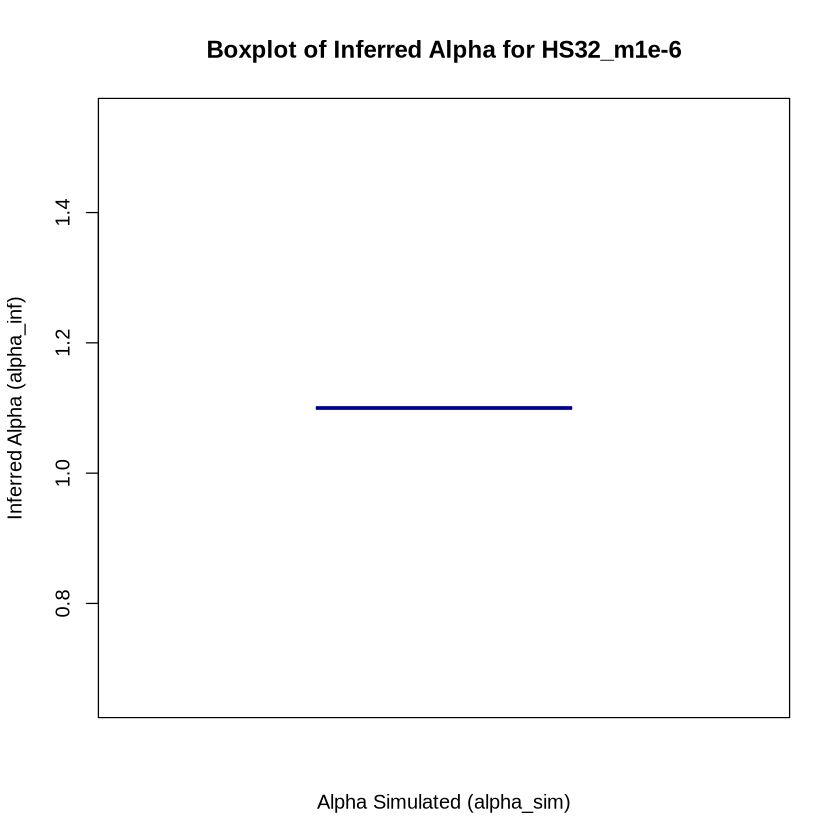

[1] "alpha_sim" "alpha_inf"


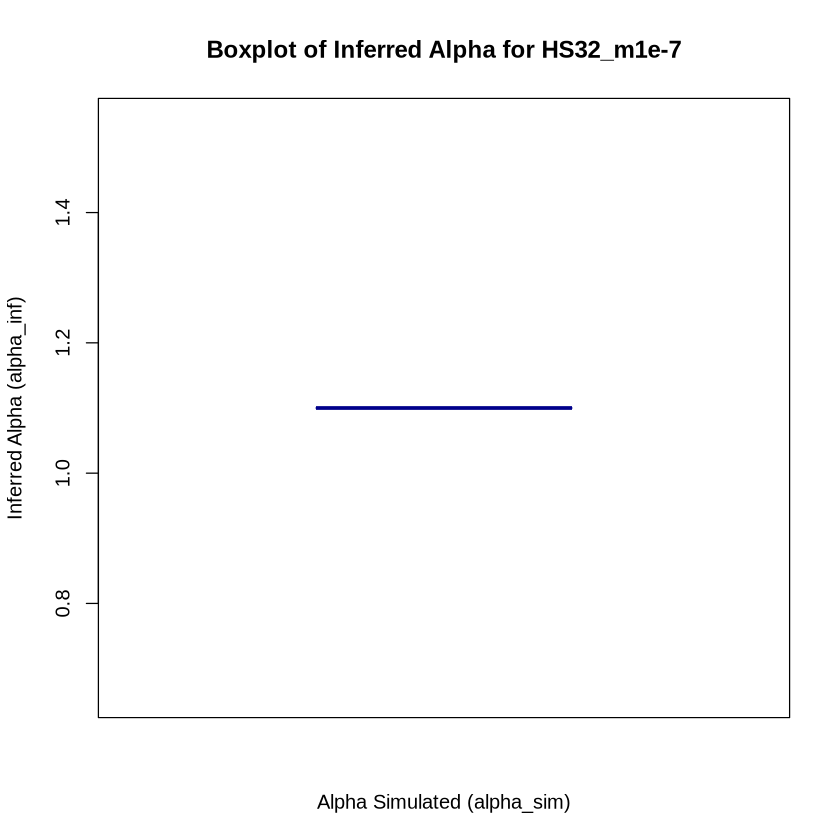

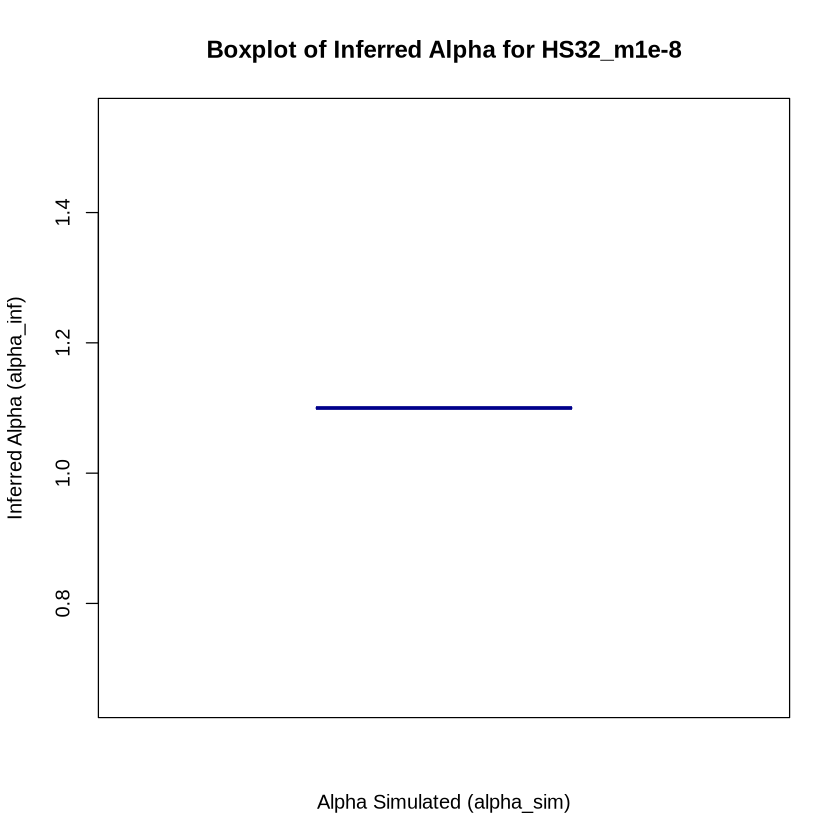

In [195]:
## Set background color to white for the plots
par(bg = "white")

# Loop through each HS and mutation rate group and create a boxplot
for (hs in names(alpha_data)) {
  plot_data <- alpha_data[[hs]]
  print(names(plot_data))
  # Set up boxplot for alpha_sim vs alpha_inf
  boxplot(alpha_inf ~ alpha_sim, data = plot_data,
          xlab = "Alpha Simulated (alpha_sim)",
          ylab = "Inferred Alpha (alpha_inf)",
          main = paste("Boxplot of Inferred Alpha for", hs),
          col = "lightblue", border = "darkblue")
}

# Reset layout to default for any further plots
par(bg = "white")

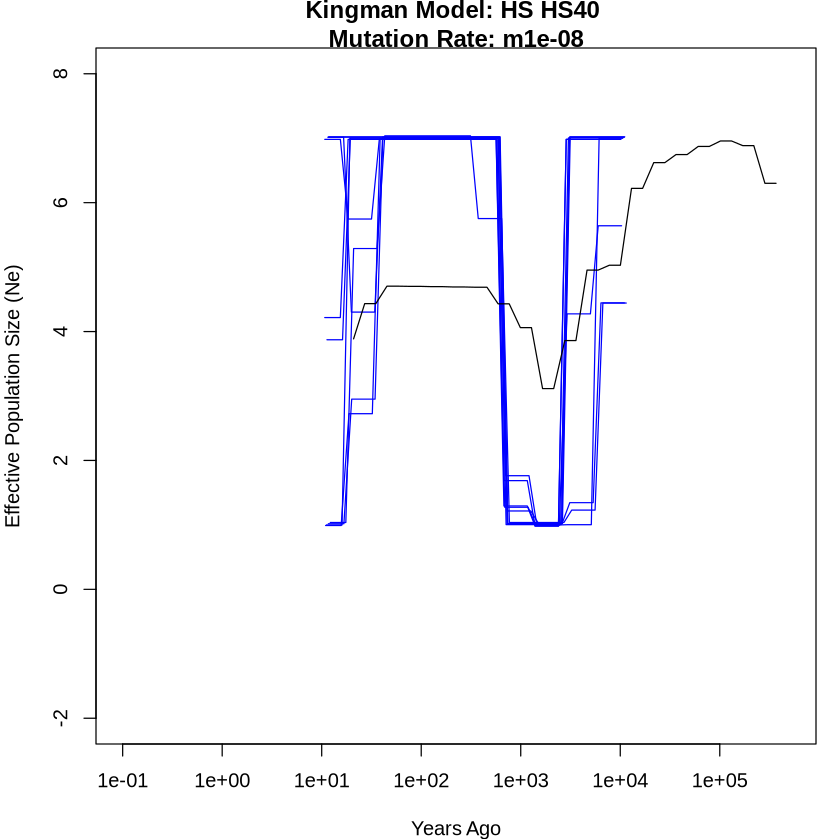

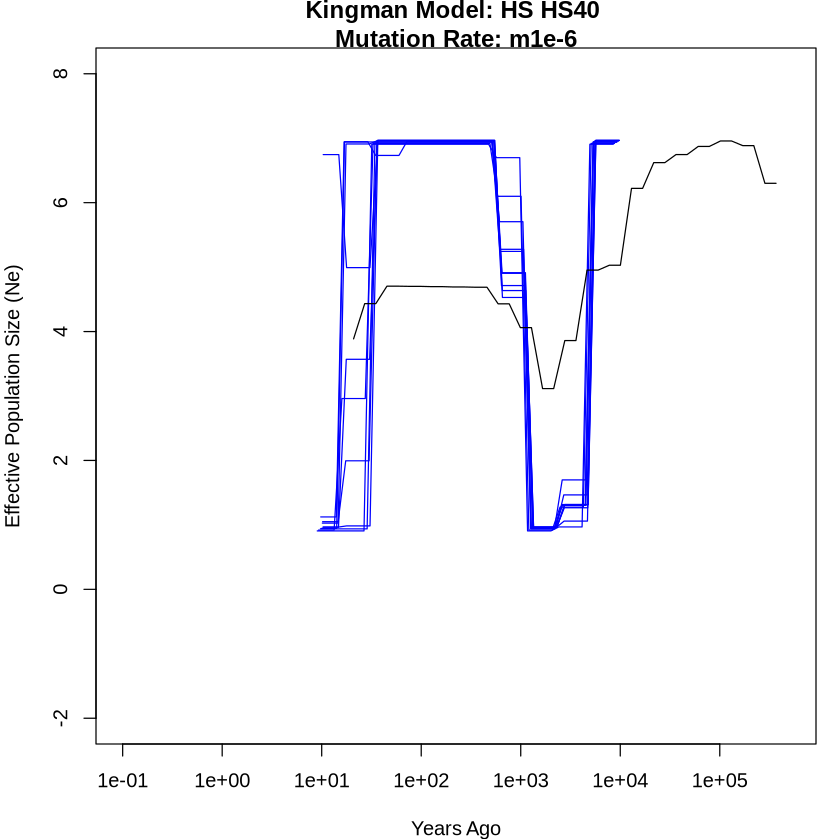

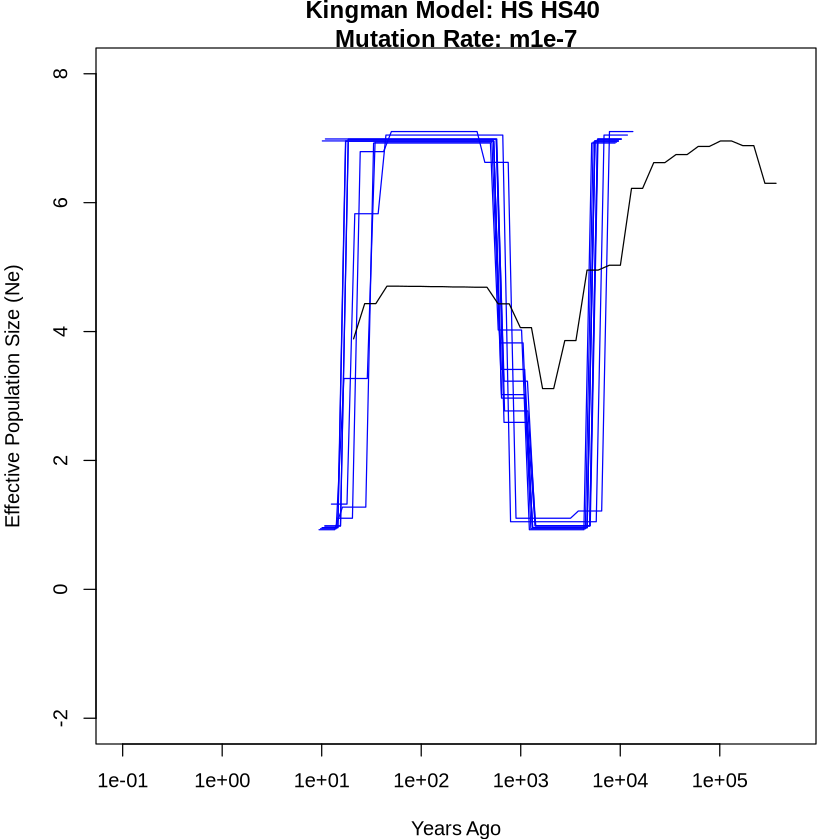

In [29]:
# Constants
gen_times <- 0.16

# Initialize a nested list to store data grouped by HS and mutation rate
hs_mu_grouped_data <- list()

# Process 'kingman' files
for (j in seq_along(rds_files_list[[2]])) {
  kingman_dir <- rds_files_list[[2]][j]
  
  # Extract the HS, mutation rate (mu) from the directory name
  path_components <- unlist(strsplit(kingman_dir, "/"))
  hs_identifier <- path_components[length(path_components) - 2]    # HS identifier (e.g., "HS_20")
  mutr_identifier <- path_components[length(path_components) - 1] # Mutation rate (e.g., "1e-07")
  mutr_numeric <- as.numeric(sub(".*(\\d+e[+-]?\\d+).*", "\\1", mutr_identifier))
  #print(mutr_numeric)
  if (file.exists(kingman_dir)) {
    data_esmc <- readRDS(kingman_dir)  # Read the .rds file

    # Perform calculations
    Ne_t <- data_esmc$Xi
    Ne <- mean(data_esmc$mu / mutr_numeric)
    alpha <- 2  # Set fixed alpha to 2 for Kingman model
    # Calculate years ago and log10 of Ne
    data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
    data_esmc$Ne <- log10(Ne_t * Ne)
    
    # Create a data frame for this file
    df <- data.frame(
      years_ago = data_esmc$years_ago,
      Ne = data_esmc$Ne,
      alpha_sim = alpha,
      alpha_inf = data_esmc$alpha  # Inferred alpha is also 2
    )
    
    # Group data by HS and mutation rate
    if (is.null(hs_mu_grouped_data[[hs_identifier]])) {
      hs_mu_grouped_data[[hs_identifier]] <- list()
    }
    if (is.null(hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]])) {
      hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]] <- list()
    }
    hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]] <- append(
      hs_mu_grouped_data[[hs_identifier]][[mutr_identifier]],
      list(df)
    )
  } else {
    warning(paste("Kingman directory does not exist:", kingman_dir))
  }
}

# Loop through each HS and mutation rate group and create plots
for (hs in names(hs_mu_grouped_data)) {
  for (mutr in names(hs_mu_grouped_data[[hs]])) {
    # Get the data frames for this HS and mutation rate group
    kingman_lines <- hs_mu_grouped_data[[hs]][[mutr]]
    
    # Set up 2x2 layout for plotting
    par( mar = c(4, 4, 2, 1), bg = "white")  # 2x2 layout for subplots
    
    # Plot for the current HS and mutation rate combination
    # Create an empty plot
    plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
         xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
         main = paste("Kingman Model: HS", hs, "\nMutation Rate:", mutr),
         log = "x", col = "black")
    
    # Plot the line for the Kingman model (alpha = 2) for this mutation rate and HS
    for (i in seq_along(kingman_lines)) {
      lines(kingman_lines[[i]]$years_ago, kingman_lines[[i]]$Ne, 
            type = "l", lty = 1, col = "blue")  # Plot with a fixed color
    }
    
    # Optional: Plot the overall demography line in black for comparison
    lines(demography_data$years_ago, demography_data$Ne, 
          type = "l", lty = 1, col = "black")  # Black overall demography line
  }
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")


    alpha_sim alpha_inf
1           2       1.1
2           2       1.1
3           2       1.1
4           2       1.1
5           2       1.1
6           2       1.1
7           2       1.1
8           2       1.1
9           2       1.1
10          2       1.1
11          2       1.1
12          2       1.1
13          2       1.1
14          2       1.1
15          2       1.1
16          2       1.1
17          2       1.1
18          2       1.1
19          2       1.1
20          2       1.1
21          2       1.1
22          2       1.1
23          2       1.1
24          2       1.1
25          2       1.1
26          2       1.1
27          2       1.1
28          2       1.1
29          2       1.1
30          2       1.1
31          2       1.1
32          2       1.1
33          2       1.1
34          2       1.1
35          2       1.1
36          2       1.1
37          2       1.1
38          2       1.1
39          2       1.1
40          2       1.1
41          2   

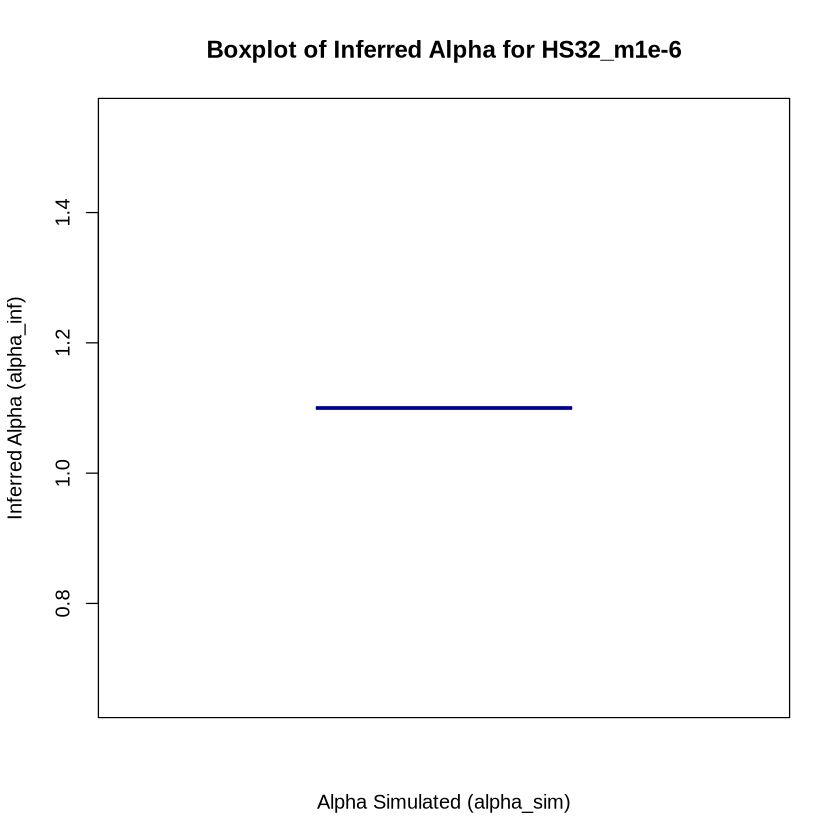

    alpha_sim alpha_inf
1           2       1.1
2           2       1.1
3           2       1.1
4           2       1.1
5           2       1.1
6           2       1.1
7           2       1.1
8           2       1.1
9           2       1.1
10          2       1.1
11          2       1.1
12          2       1.1
13          2       1.1
14          2       1.1
15          2       1.1
16          2       1.1
17          2       1.1
18          2       1.1
19          2       1.1
20          2       1.1
21          2       1.1
22          2       1.1
23          2       1.1
24          2       1.1
25          2       1.1
26          2       1.1
27          2       1.1
28          2       1.1
29          2       1.1
30          2       1.1
31          2       1.1
32          2       1.1
33          2       1.1
34          2       1.1
35          2       1.1
36          2       1.1
37          2       1.1
38          2       1.1
39          2       1.1
40          2       1.1
41          2   

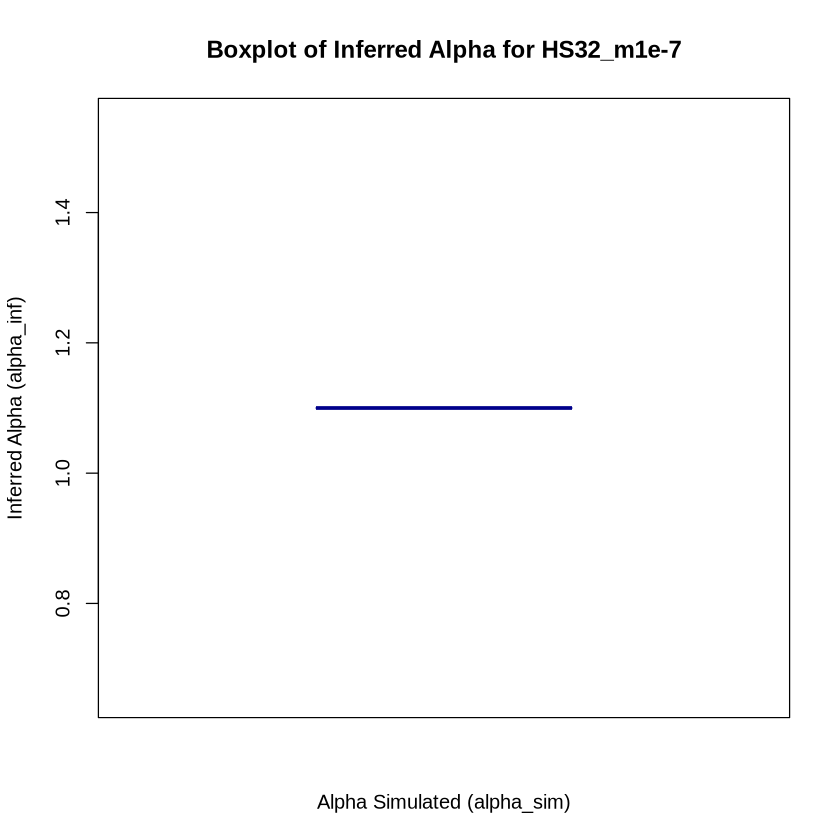

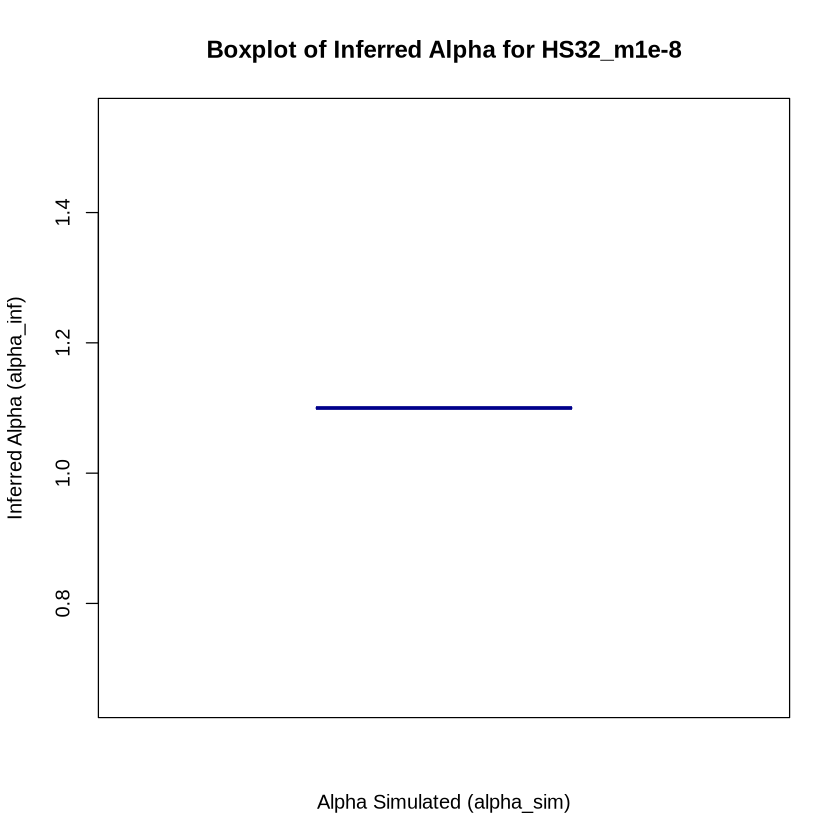

In [ ]:
# Initialize a list to collect alpha_sim and alpha_inf for each HS and mutation rate combination
alpha_data <- list()

# Loop through each HS and mutation rate group to collect alpha_sim and alpha_inf
for (hs in names(hs_mu_grouped_data)) {
  for (mutr in names(hs_mu_grouped_data[[hs]])) {
    # Get the data frames for this HS and mutation rate group
    kingman_lines <- hs_mu_grouped_data[[hs]][[mutr]]

    # Initialize vectors to store alpha_sim and alpha_inf
    alpha_sim_values <- numeric()
    alpha_inf_values <- numeric()
    
    # Loop through each line in kingman_lines and extract alpha_sim and alpha_inf
    for (entry in kingman_lines) {
      alpha_sim_values <- c(alpha_sim_values, entry$alpha_sim[1])
      alpha_inf_values <- c(alpha_inf_values, entry$alpha_inf[1])
    }
    
    # Store the values in the alpha_data list
    alpha_data[[paste(hs, mutr, sep = "_")]] <- data.frame(
      alpha_sim = alpha_sim_values,
      alpha_inf = alpha_inf_values
    )
  }
}

# Set background color to white for the plots
par(bg = "white")

# Loop through each HS and mutation rate group and create a boxplot
for (hs in names(alpha_data)) {
  plot_data <- alpha_data[[hs]]
  print(plot_data)
  # Set up boxplot for alpha_sim vs alpha_inf
  boxplot(alpha_inf ~ alpha_sim, data = plot_data,
          xlab = "Alpha Simulated (alpha_sim)",
          ylab = "Inferred Alpha (alpha_inf)",
          main = paste("Boxplot of Inferred Alpha for", hs),
          col = "lightblue", border = "darkblue")
}

# Reset layout to default for any further plots
par(bg = "white")


      

Constant popsize

In [2]:
# Define the base directory for containing all hidden states replicates.
# This directory should be at least 2 dirs deep and vary in mutation rate
kingman_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const"

# List directories in kingman_dir1 that are exactly two levels deep
kingman_subdirs1 <- list.dirs(kingman_dir1, recursive = TRUE, full.names = TRUE)
kingman_subdirs1 <- kingman_subdirs1[sapply(strsplit(kingman_subdirs1, "/"), length) == length(strsplit(kingman_dir1, "/")[[1]])+ 1]

# Initialize a list to store kingman directories categorized by mutation rate
kingman_dirs_by_mutation_rate <- list()

# Loop through each kingman directory and categorize based on mutation rate
for (kingman_dir in kingman_subdirs1) {
  # Extract the second-to-last directory as the mutation rate identifier
  mutation_rate_dir <- basename(kingman_dir)
  print(mutation_rate_dir)
  # Store the directories under the mutation rate
  if (!is.null(kingman_dirs_by_mutation_rate[[mutation_rate_dir]])) {
    kingman_dirs_by_mutation_rate[[mutation_rate_dir]] <- c(kingman_dirs_by_mutation_rate[[mutation_rate_dir]], kingman_dir)
  } else {
    kingman_dirs_by_mutation_rate[[mutation_rate_dir]] <- list(kingman_dir)
  }
}

# Format the output for better readability
kingman_dirs_by_mutation_rate

[1] "m1e-06"
[1] "m1e-07"


$`m1e-06`
$`m1e-06`[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const/m1e-06"


$`m1e-07`
$`m1e-07`[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const/m1e-07"

In [3]:
# Format the kingman directories by mutation rate
formatted_kingman_dirs <- lapply(names(kingman_dirs_by_mutation_rate), function(mutation_rate_dir) {
  list(
    mutation_rate = mutation_rate_dir,
    kingman_dirs = kingman_dirs_by_mutation_rate[[mutation_rate_dir]]
  )
})

# Display the categorized kingman directories
#print("Kingman Directories Categorized by Mutation Rate:")
print(formatted_kingman_dirs)


[[1]]
[[1]]$mutation_rate
[1] "m1e-06"

[[1]]$kingman_dirs
[[1]]$kingman_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const/m1e-06"



[[2]]
[[2]]$mutation_rate
[1] "m1e-07"

[[2]]$kingman_dirs
[[2]]$kingman_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const/m1e-07"





In [4]:
# Initialize a list to store the paths of .rds files from kingman directories
rds_files_list <- list()

# Loop through each formatted kingman directory group
for (i in seq_along(formatted_kingman_dirs)) {
  # Get the mutation rate (kingman directory identifier)

  mutation_rate <- formatted_kingman_dirs[[i]]$mutation_rate
  print(mutation_rate)
  # Get the kingman directories
  kingman_dirs <- formatted_kingman_dirs[[i]]$kingman_dirs
  print(kingman_dirs)

  # Collect the .rds files from each kingman directory
  rds_files_kingman <- unlist(lapply(kingman_dirs, function(kingman_dir) {
    list.files(path = kingman_dir, pattern = "\\.rds$", full.names = TRUE)
  }))
  
  # Store the results in the list
  rds_files_list[[mutation_rate]] <- rds_files_kingman
}



[1] "m1e-06"
[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const/m1e-06"

[1] "m1e-07"
[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/const_popsize/kingman_3haps_10mb_const/m1e-07"



In [5]:
# Constants
mu <- 1e-06
gen_times <-0.16

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[1]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[1]])) {
    beta_dir <- rds_files_list[[1]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      alpha_sim<-2
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=alpha_sim,
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}




[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9
[1] 10


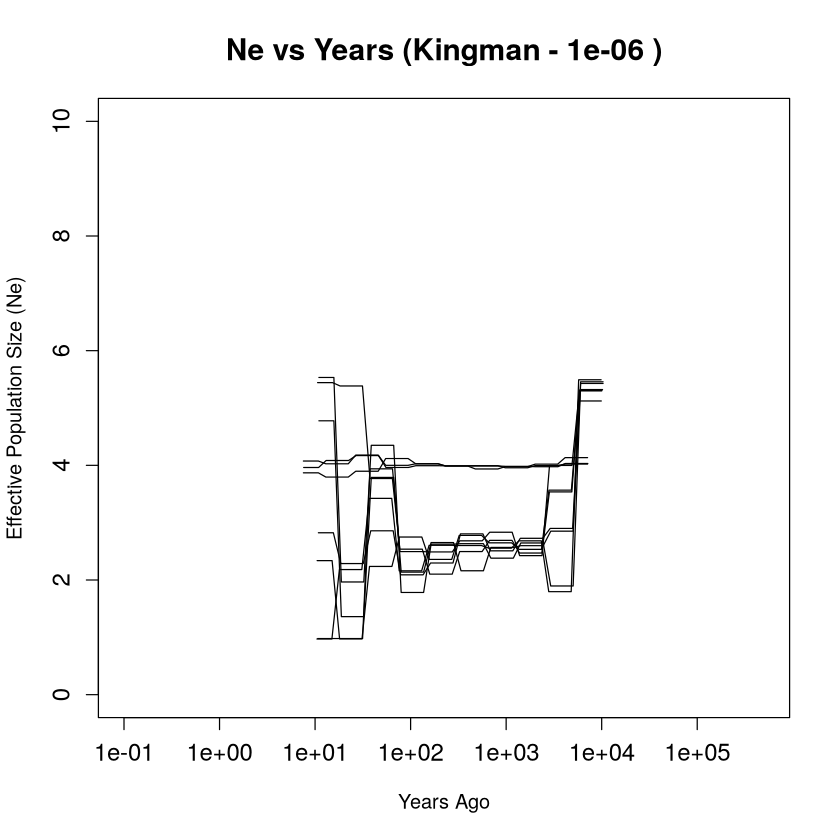

In [6]:
#Increase the plot area by making the plot longer (wider).
# Adjusting the "mfrow" or setting a custom aspect ratio.
# Change `mar` for bigger margins
par(bg = "white")  # White background for the plots


  # Set up an empty plot for the current Kingman model
plot(NULL, xlim = c(0.1, 500000), ylim = c(0, 10),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Kingman -", mu, ")"),
       log = "x", col = "black", cex.main = 1.5, cex.axis = 1.2)  # Adjust text sizes
  
# Filter Kingman data frames by the current mutation rate (mut)
kingman_lines <- individual_data_frames[[1]]

kingman_lines <- Filter(Negate(is.null), kingman_lines)  # Remove NULL entries

  # If kingman_lines is empty, skip the plot for this mutation rate
if (length(kingman_lines) > 0) {
    # Plot each line for the current mutation rate (Kingman)
    for (i in seq_along(kingman_lines)) {
      print(i) #make sure loop works
      lines(kingman_lines[[i]]$years_ago, kingman_lines[[i]]$Ne, 
            type = "l", lty = 1) 
    }
  } else {
    message("No data found for mutation rate: ", mut)
  }


# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")



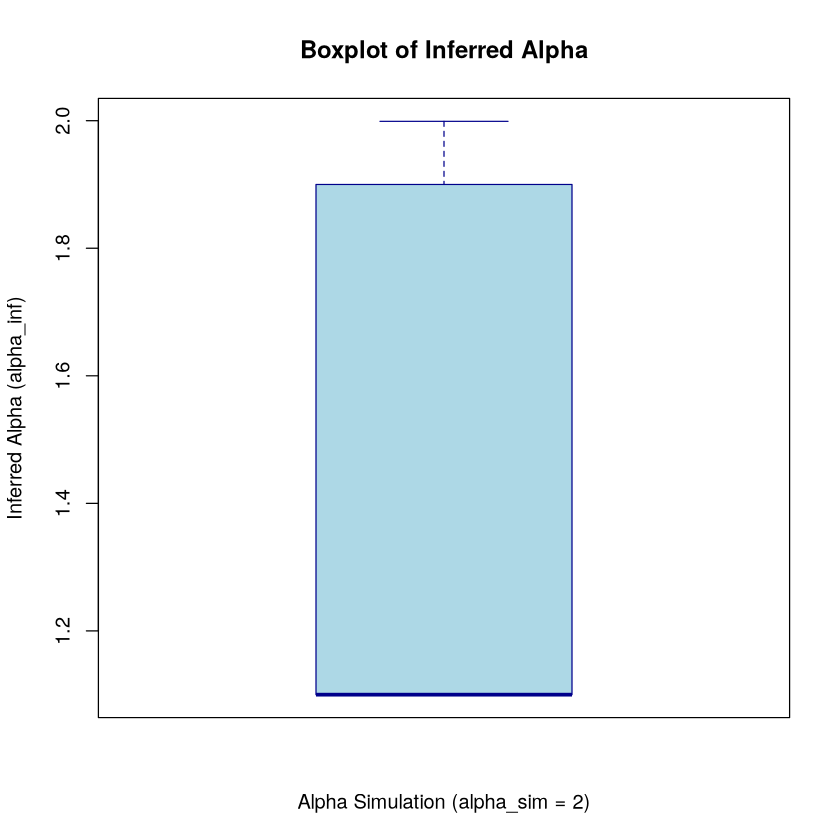

In [7]:
# Initialize a list to collect alpha_sim and alpha_inf for each HS and mutation rate combination
alpha_inf <- list()

# Constants
mu <- 1e-06
gen_times <- 0.16

# Process 'beta' files
for (j in seq_along(rds_files_list[[1]])) {
  beta_dir <- rds_files_list[[1]][j]
  
  if (file.exists(beta_dir)) {
    # Read the .rds file
    data_esmc <- readRDS(beta_dir)
    
    # Append the alpha value to the alpha_inf list
    alpha_inf[[length(alpha_inf) + 1]] <- data_esmc$alpha
  }
}

# Create a data frame for boxplot
alpha_values <- unlist(alpha_inf)  # Flatten the list of alpha values into a single vector
alpha_group <- rep(2, length(alpha_values))  # Replicate 2 for the x-axis as you mentioned alpha_sim = 2

# Create a data frame for plotting
alpha_df <- data.frame(Group = factor(alpha_group), Alpha = alpha_values)
par(bg="white")

# Create the boxplot
boxplot(Alpha ~ Group, data = alpha_df, 
        main = "Boxplot of Inferred Alpha", 
        xlab = "Alpha Simulation (alpha_sim = 2)", 
        ylab = "Inferred Alpha (alpha_inf)", 
        col = "lightblue", 
        border = "darkblue")


In [8]:
alpha_inf

[[1]]
[1] 1.9

[[2]]
[1] 1.1

[[3]]
[1] 1.999

[[4]]
[1] 1.1

[[5]]
[1] 1.999

[[6]]
[1] 1.1

[[7]]
[1] 1.1

[[8]]
[1] 1.1

[[9]]
[1] 1.1

[[10]]
[1] 1.1

In [158]:
# Constants
mu <- 1e-07
gen_times <-0.16

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[2]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[2]])) {
    beta_dir <- rds_files_list[[2]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      alpha_sim<-2
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=alpha_sim,
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}

[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9
[1] 10


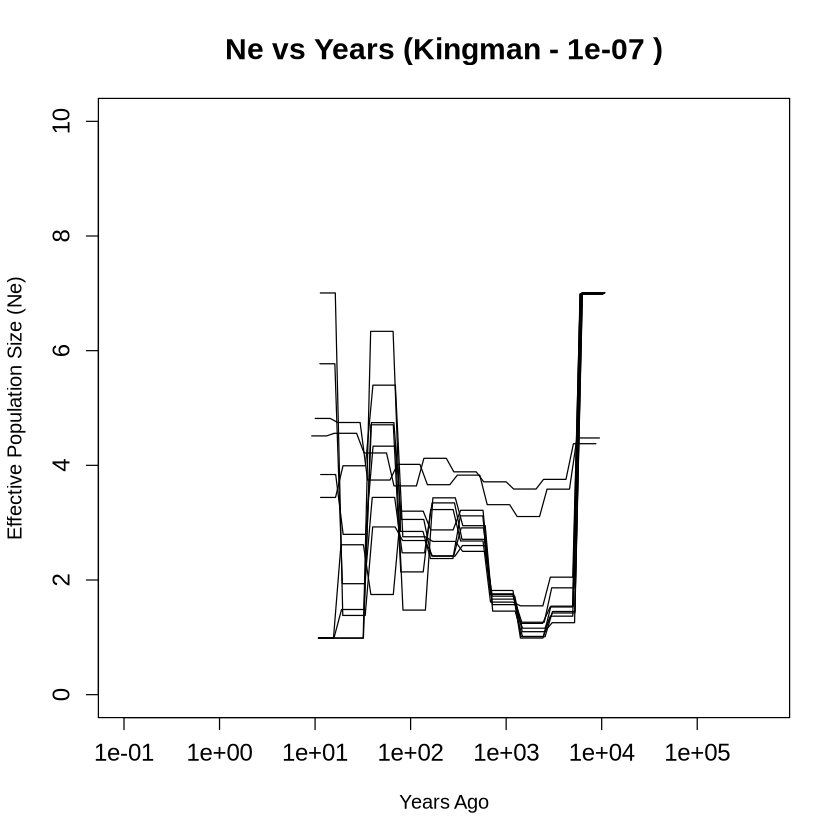

In [159]:
#Increase the plot area by making the plot longer (wider).
# Adjusting the "mfrow" or setting a custom aspect ratio.
# Change `mar` for bigger margins
par(bg = "white")  # White background for the plots


  # Set up an empty plot for the current Kingman model
plot(NULL, xlim = c(0.1, 500000), ylim = c(0, 10),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Kingman -", mu, ")"),
       log = "x", col = "black", cex.main = 1.5, cex.axis = 1.2)  # Adjust text sizes
  
# Filter Kingman data frames by the current mutation rate (mut)
kingman_lines <- individual_data_frames[[2]]

kingman_lines <- Filter(Negate(is.null), kingman_lines)  # Remove NULL entries

  # If kingman_lines is empty, skip the plot for this mutation rate
if (length(kingman_lines) > 0) {
    # Plot each line for the current mutation rate (Kingman)
    for (i in seq_along(kingman_lines)) {
      print(i) #make sure loop works
      lines(kingman_lines[[i]]$years_ago, kingman_lines[[i]]$Ne, 
            type = "l", lty = 1) 
    }
  } 


# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")



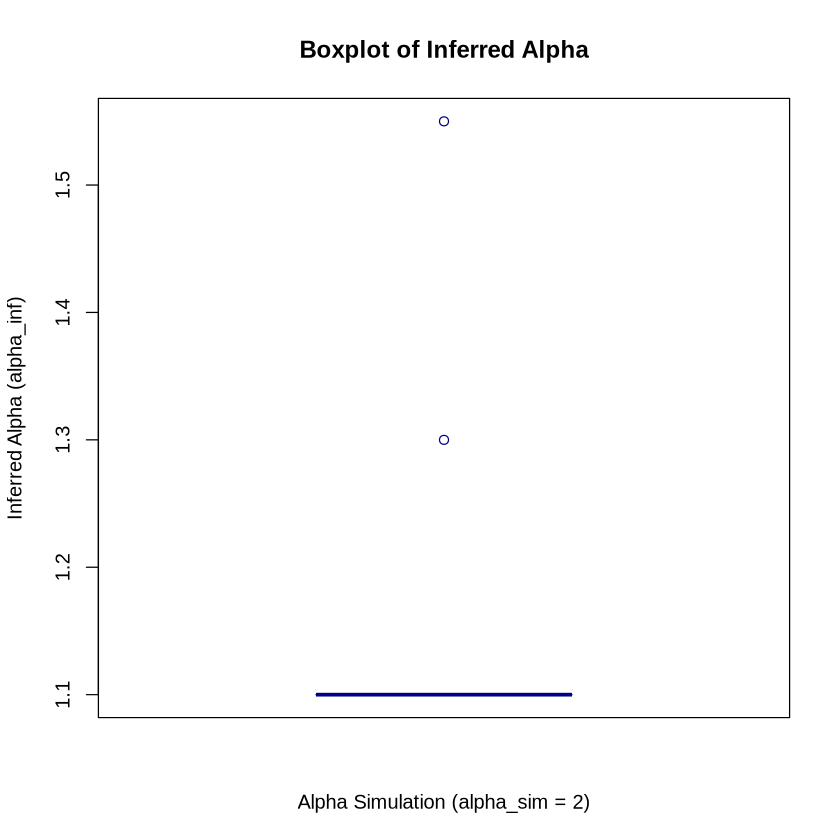

In [154]:
# Initialize a list to collect alpha_sim and alpha_inf for each HS and mutation rate combination
alpha_inf <- list()

# Process 'beta' files
for (j in seq_along(rds_files_list[[2]])) {
  beta_dir <- rds_files_list[[2]][j]
  
  if (file.exists(beta_dir)) {
    # Read the .rds file
    data_esmc <- readRDS(beta_dir)
    
    # Append the alpha value to the alpha_inf list
    alpha_inf[[length(alpha_inf) + 1]] <- data_esmc$alpha
  }
}

# Create a data frame for boxplot
alpha_values <- unlist(alpha_inf)  # Flatten the list of alpha values into a single vector
alpha_group <- rep(2, length(alpha_values))  # Replicate 2 for the x-axis as you mentioned alpha_sim = 2

# Create a data frame for plotting
alpha_df <- data.frame(Group = factor(alpha_group), Alpha = alpha_values)
par(bg="white")

# Create the boxplot
boxplot(Alpha ~ Group, data = alpha_df, 
        main = "Boxplot of Inferred Alpha", 
        xlab = "Alpha Simulation (alpha_sim = 2)", 
        ylab = "Inferred Alpha (alpha_inf)", 
        col = "lightblue", 
        border = "darkblue")
